# 01 — Exploratory data analysis: Inside Airbnb proxy dataset

Reproducible from `data/raw/listings.csv.gz` (Inside Airbnb, Sydney, scraped
17–29 June 2026). Run top to bottom with the project environment; no cell
writes to disk.

The Career Mentor platform data has not been received, so this dataset is a
**structural proxy**: provider attributes + performance + demand → price. It
is not a claim that accommodation and mentorship pricing behave alike.

This notebook documents the evidence behind the data decisions encoded in
`src/config.py` and `src/preprocessing/`. Feature lists are imported from the
config rather than restated, so the analysis always describes the features the
models actually use.

**Contents**
1. Row counts and the missing-price exclusion
2. Fully empty columns
3. Missing rates per feature category
4. Target distribution: raw vs log price
5. Target leakage
6. `property_type` / `room_type` collinearity
7. Outlier capping: capped vs exempt columns
8. Findings and decisions

In [1]:
import sys
from pathlib import Path

# Locate the project root whether the kernel starts in notebooks/ or the root.
PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config
from src.data.loader import load_raw_csv
from src.preprocessing import parse_price

pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Reference palette: capped vs exempt is a two-way identity, so it takes
# categorical slots 1 and 2. Text stays in ink colours, never series colours.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "legend.frameon": False,
        "font.size": 9,
    }
)

In [2]:
import platform

import matplotlib
import sklearn

# Versions used to produce the outputs below; compare with requirements.txt.
pd.Series(
    {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "scikit-learn": sklearn.__version__,
        "matplotlib": matplotlib.__version__,
    },
    name="version",
).to_frame()

,version
python,3.13.7
pandas,2.2.3
numpy,2.1.3
scikit-learn,1.5.2
matplotlib,3.9.3


## 1. Row counts and the missing-price exclusion

In [3]:
raw = load_raw_csv("listings.csv.gz")
price = parse_price(raw[config.TARGET_VARIABLE])
priced = raw.loc[price.notna()].assign(price_num=price[price.notna()])

counts = pd.Series(
    {
        "listings (raw)": len(raw),
        "columns (raw)": raw.shape[1],
        "unique listing ids": raw["id"].nunique(),
        "missing price": int(price.isna().sum()),
        "listings kept (price present)": len(priced),
    }
)
print(f"Scrape window: {raw['last_scraped'].min()} to {raw['last_scraped'].max()}")
print(f"Missing price rate: {price.isna().mean():.1%}")
counts.to_frame("count")

Scrape window: 2026-06-17 to 2026-06-29
Missing price rate: 13.5%


,count
listings (raw),20573
columns (raw),90
unique listing ids,20573
missing price,2787
listings kept (price present),17786


Missing prices are not random. Most listings without a price are inactive:
74% have zero availability for the coming year, while no priced listing does,
and they are twice as likely to have had no reviews in the last twelve months.
Dropping them is therefore an **exclusion rule** (inactive listings have no
current listed price to predict), not missingness to impute.

In [4]:
ACTIVITY_COLUMNS = ["availability_365", "number_of_reviews_ltm"]
missing = price.isna()
activity = pd.DataFrame(
    {
        "price missing": [
            (raw.loc[missing, c] == 0).mean() for c in ACTIVITY_COLUMNS
        ],
        "price present": [
            (raw.loc[~missing, c] == 0).mean() for c in ACTIVITY_COLUMNS
        ],
    },
    index=[f"share with {c} == 0" for c in ACTIVITY_COLUMNS],
)
activity.style.format("{:.1%}")

,price missing,price present
share with availability_365 == 0,74.2%,0.0%
share with number_of_reviews_ltm == 0,50.8%,25.1%


## 2. Fully empty columns

In [5]:
empty_columns = [c for c in raw.columns if raw[c].isna().all()]
print(f"{len(empty_columns)} of {raw.shape[1]} columns are entirely empty:")
pd.Series(empty_columns, name="column").to_frame()

13 of 90 columns are entirely empty:


,column
0,neighborhood_overview
1,host_since
2,host_response_time
3,host_response_rate
4,host_acceptance_rate
5,host_thumbnail_url
6,host_neighbourhood
7,host_total_listings_count
8,host_verifications
9,neighbourhood


These cannot be features. Three of them matter for the conceptual framework:
`host_response_rate`, `host_acceptance_rate` and `host_response_time` were the
closest analogues of mentor **completion rate**, so the performance category has
no completion-rate proxy in this snapshot. `host_since` is replaced by the
populated `hosts_time_as_host_years` + `hosts_time_as_host_months` pair.

In [6]:
experience = raw[["hosts_time_as_host_years", "hosts_time_as_host_months"]]
experience.describe().loc[["min", "max", "mean"]]

,hosts_time_as_host_years,hosts_time_as_host_months
min,0.000000,0.000000
max,15.000000,11.000000
mean,5.410149,5.568804


`hosts_time_as_host_months` only runs 0–11: it is the remainder after whole
years, not total tenure. Both columns are therefore kept as features (total
months = years × 12 + months, which a linear model can represent exactly).

## 3. Missing rates per feature category

Rates are computed on the priced rows — the rows the models train on — for the
configured feature lists in `src/config.py`.

In [7]:
CATEGORIES = {
    "Mentor profile": config.MENTOR_PROFILE_FEATURES,
    "Mentor performance": config.MENTOR_PERFORMANCE_FEATURES,
    "Demand indicators": config.DEMAND_INDICATOR_FEATURES,
    "Market variables": config.MARKET_FEATURES,
}
per_column = pd.concat(
    [
        pd.DataFrame(
            {"category": name, "missing rate": priced[cols].isna().mean()}
        )
        for name, cols in CATEGORIES.items()
    ]
)
summary = per_column.groupby("category", sort=False)["missing rate"].agg(
    columns="size",
    mean="mean",
    max="max",
    complete_columns=lambda s: int((s == 0).sum()),
)
summary.style.format({"mean": "{:.1%}", "max": "{:.1%}"})

,columns,mean,max,complete_columns
category,,,,
Mentor profile,10,4.6%,17.0%,7
Mentor performance,6,10.5%,15.7%,2
Demand indicators,6,2.6%,15.7%,5
Market variables,3,0.0%,0.0%,3


In [8]:
per_column[per_column["missing rate"] > 0].style.format({"missing rate": "{:.1%}"})

,category,missing rate
bedrooms,Mentor profile,15.3%
bathrooms,Mentor profile,17.0%
beds,Mentor profile,13.2%
review_scores_rating,Mentor performance,15.7%
review_scores_accuracy,Mentor performance,15.7%
review_scores_communication,Mentor performance,15.7%
review_scores_value,Mentor performance,15.7%
reviews_per_month,Demand indicators,15.7%


Eight configured features have missing values, all at 13–17%; the other 17
are complete, including every market feature. The size columns (`bedrooms`,
`bathrooms`, `beds`) are missing at random-looking rates. The review-derived
columns are different: they are missing together, at the same 15.7% rate.

In [9]:
no_reviews = priced["number_of_reviews"] == 0
REVIEW_DERIVED = ["reviews_per_month", "review_scores_rating", "review_scores_value"]
pd.DataFrame(
    {
        col: {
            "missing, listing has reviews": int((priced[col].isna() & ~no_reviews).sum()),
            "missing, listing has no reviews": int((priced[col].isna() & no_reviews).sum()),
            "present, listing has no reviews": int((priced[col].notna() & no_reviews).sum()),
        }
        for col in REVIEW_DERIVED
    }
)

,reviews_per_month,review_scores_rating,review_scores_value
"missing, listing has reviews",0,0,2
"missing, listing has no reviews",2792,2792,2792
"present, listing has no reviews",0,0,0


Review-derived columns are missing **exactly** for the 2,792 listings with no
reviews (the two `review_scores_value` gaps aside). That missingness is
informative, and median imputation misrepresents it:

- `reviews_per_month` is truly **0** for these listings, but median imputation
  assigns them the median of reviewed listings (about 1.1 per month).
- Review scores do not exist for them, but median imputation presents them as
  typically rated hosts.

The current pipeline applies median imputation to these columns. See the open
questions at the end.

## 4. Target distribution: raw vs log price

In [10]:
p = priced["price_num"]
describe = p.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
shape = pd.Series(
    {
        "skewness (raw)": p.skew(),
        "skewness (log1p)": np.log1p(p).skew(),
        "listings <= $10": (p <= 10).sum(),
        "listings > $1,000": (p > 1000).sum(),
        "listings > $5,000": (p > 5000).sum(),
    }
)
display(describe.round(2).to_frame("price ($)"))
shape.round(2).to_frame("value")

,price ($)
count,17786.00
mean,431.65
std,893.65
min,1.74
1%,22.68
5%,59.00
25%,169.73
50%,291.00
75%,445.33
95%,1147.46


,value
skewness (raw),24.57
skewness (log1p),-0.09
listings <= $10,17.00
"listings > $1,000",1121.00
"listings > $5,000",68.00


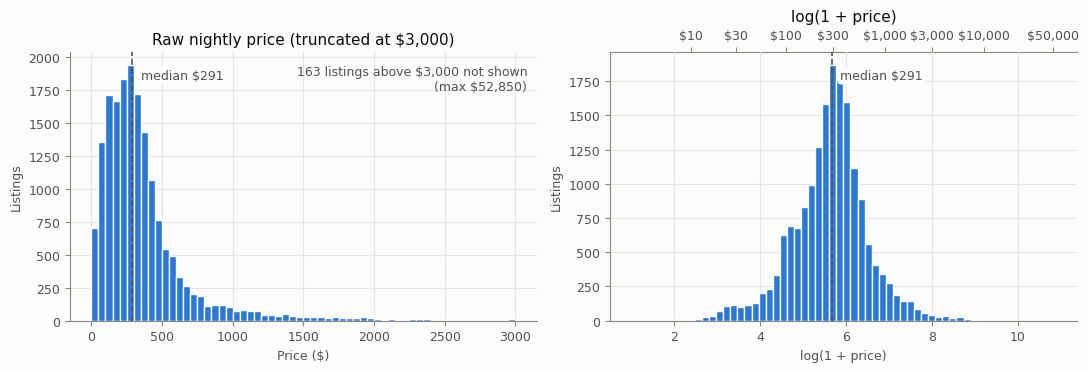

In [11]:
fig, (ax_raw, ax_log) = plt.subplots(1, 2, figsize=(11, 3.8))

ax_raw.hist(p, bins=np.arange(0, 3001, 50), color=BLUE, edgecolor=SURFACE, linewidth=1)
ax_raw.set_title("Raw nightly price (truncated at $3,000)")
ax_raw.set_xlabel("Price ($)")
ax_raw.set_ylabel("Listings")
over = (p > 3000).sum()
ax_raw.text(0.98, 0.95, f"{over} listings above $3,000 not shown\n(max ${p.max():,.0f})",
            transform=ax_raw.transAxes, ha="right", va="top", color=INK_2)

log_p = np.log1p(p)
ax_log.hist(log_p, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=1)
ax_log.set_title("log(1 + price)")
ax_log.set_xlabel("log(1 + price)")
ax_log.set_ylabel("Listings")
ticks = [10, 30, 100, 300, 1000, 3000, 10000, 50000]
top = ax_log.secondary_xaxis("top", functions=(np.expm1, np.log1p))
top.set_xticks(ticks)
top.set_xticklabels([f"${t:,}" for t in ticks])
top.tick_params(colors=MUTED, labelcolor=INK_2)

for ax, median in [(ax_raw, p.median()), (ax_log, np.log1p(p.median()))]:
    ax.axvline(median, color=INK_2, linewidth=1.2, linestyle="--")
    ax.annotate(f"median ${p.median():,.0f}", (median, 0.9), xycoords=("data", "axes fraction"),
                xytext=(6, 0), textcoords="offset points", color=INK_2,
                bbox={"boxstyle": "round,pad=0.2", "facecolor": SURFACE, "edgecolor": "none"})

fig.tight_layout()
plt.show()

Raw price is extremely right-skewed; `log1p` makes it close to symmetric. The
models are trained on log price and predictions are transformed back to dollars
(`with_price_target` in `src/preprocessing/target.py`).

Where to cap the target follows from the same comparison. Tukey fences
(Q1 − 1.5·IQR, Q3 + 1.5·IQR) computed on the raw scale versus the log scale:

In [12]:
def tukey_fences(s, k=config.IQR_MULTIPLIER):
    q1, q3 = s.quantile([0.25, 0.75])
    return q1 - k * (q3 - q1), q3 + k * (q3 - q1)


rows = {}
for scale, series, back in [("raw", p, lambda v: v), ("log1p", log_p, np.expm1)]:
    lo, hi = (back(v) for v in tukey_fences(series))
    rows[scale] = {
        "lower fence ($)": lo,
        "upper fence ($)": hi,
        "capped below": (p < lo).mean(),
        "capped above": (p > hi).mean(),
    }
fences = pd.DataFrame(rows).T
fences.style.format(
    {"lower fence ($)": "{:,.2f}", "upper fence ($)": "{:,.2f}",
     "capped below": "{:.1%}", "capped above": "{:.1%}"}
)

,lower fence ($),upper fence ($),capped below,capped above
raw,-243.68,858.74,0.0%,8.1%
log1p,39.39,"1,885.66",3.1%,2.2%


On the raw scale the lower fence is negative (no effect) and the upper fence
caps 8% of listings at about \$860, so the model could never predict a price
above that. On the log scale the fences cap about 5% of listings across both
tails, at roughly \$39 and \$1,900. The target is therefore **capped on the log
scale**, with fences learned from the training fold only.

(The pipeline fits these fences on each training split, so the exact values in
production differ slightly from these full-data figures.)

## 5. Target leakage

Two columns are computed from the listed price. Used as features they would let
the model read the answer.

In [13]:
rev = priced["estimated_revenue_l365d"]
occ = priced["estimated_occupancy_l365d"]
quote = parse_price(priced["price_quote_price_per_night"])
has_occ = occ > 0

leakage = pd.DataFrame(
    {
        "rows compared": [int(has_occ.sum()), int(quote.notna().sum())],
        "exact match (within 1%)": [
            np.isclose(rev[has_occ], occ[has_occ] * p[has_occ], rtol=0.01).mean(),
            np.isclose(quote[quote.notna()], p[quote.notna()], rtol=0.01).mean(),
        ],
    },
    index=[
        "estimated_revenue_l365d == occupancy × price",
        "price_quote_price_per_night == price",
    ],
)
leakage.style.format({"exact match (within 1%)": "{:.2%}"})

,rows compared,exact match (within 1%)
estimated_revenue_l365d == occupancy × price,13319,100.00%
price_quote_price_per_night == price,17784,100.00%


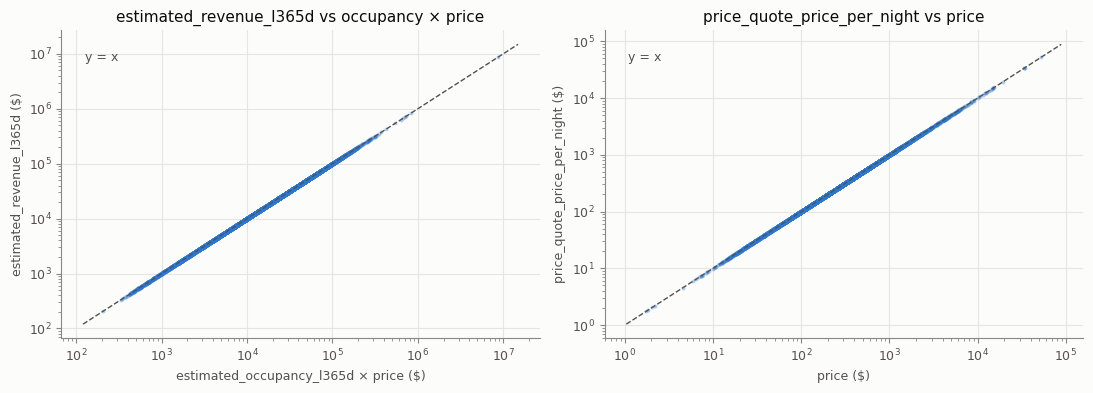

In [14]:
fig, (ax_rev, ax_quote) = plt.subplots(1, 2, figsize=(11, 4))

x = (occ * p)[has_occ]
ax_rev.scatter(x, rev[has_occ], s=8, color=BLUE, alpha=0.35, linewidths=0)
ax_rev.set_title("estimated_revenue_l365d vs occupancy × price")
ax_rev.set_xlabel("estimated_occupancy_l365d × price ($)")
ax_rev.set_ylabel("estimated_revenue_l365d ($)")

ax_quote.scatter(p[quote.notna()], quote[quote.notna()], s=8, color=BLUE, alpha=0.35,
                 linewidths=0)
ax_quote.set_title("price_quote_price_per_night vs price")
ax_quote.set_xlabel("price ($)")
ax_quote.set_ylabel("price_quote_price_per_night ($)")

for ax in (ax_rev, ax_quote):
    ax.set_xscale("log")
    ax.set_yscale("log")
    lo, hi = ax.get_xlim()
    ax.plot([lo, hi], [lo, hi], color=INK_2, linewidth=1, linestyle="--")
    ax.annotate("y = x", (0.05, 0.9), xycoords="axes fraction", color=INK_2)

fig.tight_layout()
plt.show()

Every point lies on the identity line. Both columns — and the rest of the
`price_quote_*` family, which comes from the same quote — are listed in
`config.TARGET_LEAKAGE_COLUMNS` and excluded from both feature sets:

In [15]:
leak = set(config.TARGET_LEAKAGE_COLUMNS)
pd.Series(
    {
        "baseline": sorted(leak & set(config.baseline_feature_set())),
        "full": sorted(leak & set(config.full_feature_set())),
    },
    name="leaking columns present",
).to_frame()

,leaking columns present
baseline,[]
full,[]


## 6. `property_type` / `room_type` collinearity

`property_type` (e.g. "Shared room in home") largely nests `room_type`
("Shared room"): almost every property type belongs to a single room type.

In [16]:
room_types_per_property = priced.groupby("property_type")["room_type"].nunique()
print(f"{priced['property_type'].nunique()} property types; "
      f"{(room_types_per_property == 1).sum()} map to exactly one room type")

type_counts = priced["property_type"].value_counts()
print(f"{(type_counts == 1).sum()} property types occur in a single priced listing; "
      f"{(type_counts < 10).sum()} occur in fewer than 10")

crosstab = pd.crosstab(priced["property_type"], priced["room_type"])
spanning = room_types_per_property[room_types_per_property > 1].index
display(crosstab.loc[spanning].rename_axis("property types spanning room types"))
crosstab.loc[crosstab.index.str.startswith("Shared room")]

65 property types; 62 map to exactly one room type
17 property types occur in a single priced listing; 33 occur in fewer than 10


room_type,Entire home/apt,Hotel room,Private room,Shared room
property types spanning room types,,,,
Room in aparthotel,35,6,83,0
Room in boutique hotel,0,36,77,0
Room in hotel,1,1,190,0


room_type,Entire home/apt,Hotel room,Private room,Shared room
property_type,,,,
Shared room in bed and breakfast,0,0,0,1
Shared room in condo,0,0,0,1
Shared room in home,0,0,0,7
Shared room in hostel,0,0,0,21
Shared room in hotel,0,0,0,1
Shared room in rental unit,0,0,0,6
Shared room in riad,0,0,0,2


The three exceptions are hotel-style rooms split across "Entire home/apt",
"Hotel room" and "Private room", so those room types are not exact sums of
property types. "Shared room" is: every
listing in it has a "Shared room in …" property type and no such property type
appears under any other room type. After one-hot encoding, the "Shared room"
indicator therefore equals the sum of those property-type indicators, and with
both variables in the design matrix it is rank-deficient even after dropping a
reference level per variable:

In [17]:
def design_rank(columns):
    encoded = pd.get_dummies(priced[columns], drop_first=True, dtype=float)
    matrix = np.column_stack([np.ones(len(encoded)), encoded.to_numpy()])
    return matrix.shape[1], np.linalg.matrix_rank(matrix)


ranks = pd.DataFrame(
    [design_rank(cols) for cols in (["room_type"], ["property_type"],
                                    ["room_type", "property_type"])],
    index=["room_type only", "property_type only", "both"],
    columns=["columns (incl. intercept)", "rank"],
)
ranks["rank deficiency"] = ranks.iloc[:, 0] - ranks["rank"]
ranks

,columns (incl. intercept),rank,rank deficiency
room_type only,4,4,0
property_type only,65,65,0
both,68,67,1


Rank deficiency means Linear Regression has no unique solution. In practice
it returned offsetting coefficients of order 10¹³ that cancel on the training
rows. Any test listing with a property type unseen in training (common: many
types occur once) breaks the cancellation, and the predicted log price
overflowed.

`property_type` was removed from the feature set; `room_type` keeps the coarse
signal with 4 stable levels. One-hot encoding also drops a reference level per
variable, which removes the separate collinearity between each full indicator
block and the intercept.

## 7. Outlier capping: capped vs exempt columns

IQR capping is opt-in (`config.CAPPED_FEATURES`): heavily right-skewed counts,
where a few extreme values would compress everyone else after Min-Max scaling.
Rating and size columns are exempt: their "outliers" are genuine and
informative (a 1-star host; a 10-bedroom house). The dashed lines are the Tukey
fences that capping would apply; the share of priced listings outside them is
in each panel title.

In [18]:
RATING = [c for c in config.full_feature_set() if c.startswith("review_scores_")]
SIZE = ["accommodates", "bedrooms", "beds"]
panels = [(c, "capped") for c in config.CAPPED_FEATURES] + [
    (c, "exempt") for c in RATING + SIZE
]

rows = []
for column, group in panels:
    s = priced[column].dropna()
    lo, hi = tukey_fences(s)
    rows.append(
        {
            "column": column,
            "group": group,
            "min": s.min(),
            "median": s.median(),
            "max": s.max(),
            "lower fence": lo,
            "upper fence": hi,
            "outside fences": ((s < lo) | (s > hi)).mean(),
        }
    )
fence_table = pd.DataFrame(rows).set_index("column")
fence_table.style.format(
    {"outside fences": "{:.1%}", "min": "{:,.2f}", "median": "{:,.2f}", "max": "{:,.2f}",
     "lower fence": "{:,.2f}", "upper fence": "{:,.2f}"}
)

,group,min,median,max,lower fence,upper fence,outside fences
column,,,,,,,
host_listings_count,capped,0.00,4.00,667.00,-33.50,58.50,12.2%
bathrooms,capped,0.50,1.00,21.00,-0.50,3.50,2.1%
number_of_reviews,capped,0.00,13.00,"1,158.00",-65.50,114.50,10.0%
number_of_reviews_ltm,capped,0.00,5.00,310.00,-25.50,42.50,5.1%
number_of_reviews_l30d,capped,0.00,0.00,31.00,-1.50,2.50,10.0%
reviews_per_month,capped,0.01,1.11,54.71,-2.23,4.86,3.4%
review_scores_rating,exempt,1.00,4.83,5.00,4.14,5.46,6.6%
review_scores_accuracy,exempt,0.00,4.86,5.00,4.23,5.43,6.4%
review_scores_communication,exempt,0.00,4.94,5.00,4.55,5.27,8.7%


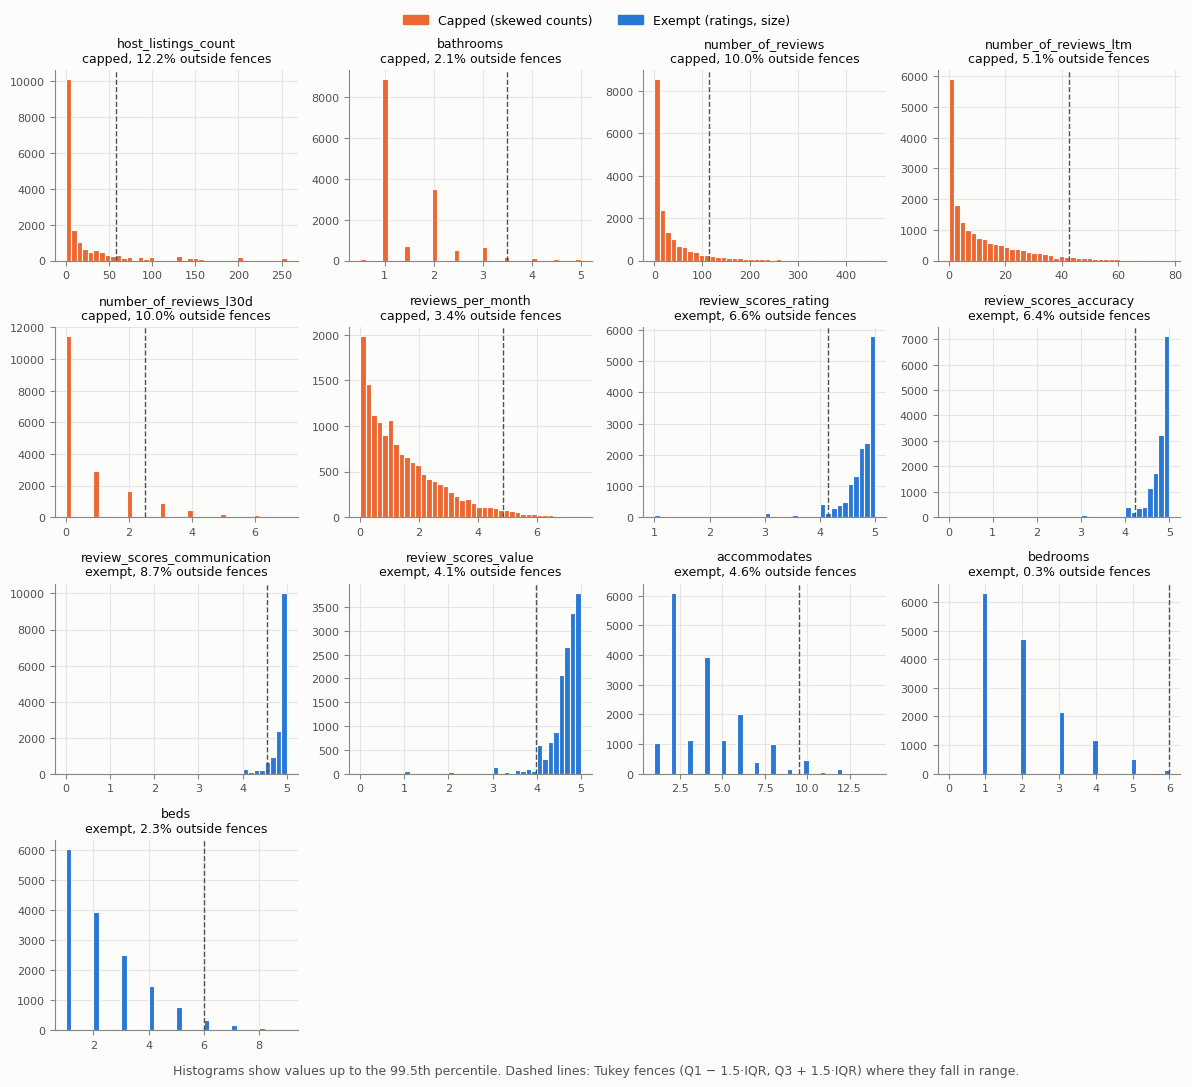

In [19]:
ncols = 4
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.6 * nrows))
colors = {"capped": ORANGE, "exempt": BLUE}

for ax, (column, group) in zip(axes.flat, panels):
    s = priced[column].dropna()
    row = fence_table.loc[column]
    upper = s.quantile(0.995)  # trim the long tail so the bulk is visible
    shown = s[s <= upper]
    ax.hist(shown, bins=40, color=colors[group], edgecolor=SURFACE, linewidth=0.8)
    for fence in (row["lower fence"], row["upper fence"]):
        if shown.min() <= fence <= shown.max():
            ax.axvline(fence, color=INK_2, linewidth=1, linestyle="--")
    ax.set_title(f"{column}\n{group}, {row['outside fences']:.1%} outside fences",
                 fontsize=9)
    ax.tick_params(labelsize=8)

for ax in list(axes.flat)[len(panels):]:
    ax.set_visible(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
fig.legend(handles, ["Capped (skewed counts)", "Exempt (ratings, size)"],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.text(0.5, -0.01, "Histograms show values up to the 99.5th percentile. "
         "Dashed lines: Tukey fences (Q1 − 1.5·IQR, Q3 + 1.5·IQR) where they fall in range.",
         ha="center", color=INK_2)
fig.tight_layout()
plt.show()

- **Capped columns** have long right tails: review counts and
  `host_listings_count` (one host manages hundreds of listings) would otherwise
  squash typical values into a narrow band after Min-Max scaling.
- **Rating columns** are left-skewed and tightly packed near 5. The lower fences
  sit between about 4.0 and 4.6, so capping `review_scores_rating` would make a
  1-star host indistinguishable from a 4.1-star one: exactly the variation that
  should inform price. (The low scores are real but rare, so their bars are
  barely visible above.)
- **Size columns** have few values outside the fences, but those are the large
  properties that command the highest prices. Size is the strongest single
  predictor in the data (see below), so it is not capped.
- `bathrooms` is capped as a skewed count; its maximum (21) is implausible for
  a single listing.

In [20]:
correlations = (
    priced[config.CAPPED_FEATURES + RATING + SIZE]
    .corrwith(priced["price_num"], method="spearman")
    .sort_values(key=abs, ascending=False)
)
correlations.round(3).to_frame("Spearman correlation with price")

,Spearman correlation with price
accommodates,0.688
beds,0.667
bedrooms,0.622
bathrooms,0.468
review_scores_rating,0.218
review_scores_accuracy,0.195
review_scores_communication,0.157
review_scores_value,0.079
host_listings_count,0.070
number_of_reviews_ltm,0.067


## 8. Findings and decisions

| # | Finding | Decision | Where |
|---|---|---|---|
| 1 | 20,573 listings; 2,787 (13.5%) have no price, and 74% of those have zero availability for the year (0% of priced listings do). | Drop listings without a price as an exclusion rule, leaving **17,786**. | `split_features_and_target` |
| 2 | 13 columns are entirely empty, including all three host response/acceptance fields. | Not used. The performance category has **no completion-rate proxy** in this dataset — a stated limitation. | `config.py` comment |
| 3 | `hosts_time_as_host_months` is only the 0–11 remainder after whole years. | Use both `hosts_time_as_host_years` and `hosts_time_as_host_months`. | `MENTOR_PROFILE_FEATURES` |
| 4 | 17 of 25 configured features are complete; eight have 13–17% missing. | Median imputation (continuous), mode imputation (categorical), fitted per training fold. | `build_preprocessor` |
| 5 | Price skewness 24.6 raw vs −0.09 after `log1p`; maximum \$52,850. | Train on `log1p(price)`, predict in dollars. | `with_price_target` |
| 6 | Tukey fences on raw price cap 8% of listings at ~\$860; on log price they cap ~5% across both tails. | Cap the target **on the log scale**, fences learned from training data only. | `build_target_transformer` |
| 7 | `estimated_revenue_l365d` = occupancy × price and `price_quote_price_per_night` = price for every comparable row. | Exclude both, and the whole `price_quote_*` family, from both feature sets. | `TARGET_LEAKAGE_COLUMNS` |
| 8 | `property_type` nests "Shared room" exactly (and 62 of 65 types map to one room type); together they make the design matrix rank-deficient, and Linear Regression predictions overflowed on unseen property types. | Drop `property_type`, keep `room_type`. One-hot encode with a dropped reference level. | `config.py`, `build_preprocessor` |
| 9 | Skewed counts have long right tails; ratings and size have genuine, informative extremes. | IQR-cap only `CAPPED_FEATURES`; ratings, size, coordinates, experience and availability are exempt. | `CAPPED_FEATURES` |

**Open questions**

1. **Evaluation scale.** RMSE is the primary selection criterion, and test-set
   prices are uncapped (up to \$52,850). A handful of extreme listings can
   therefore dominate RMSE and decide model selection. Whether to score against
   capped prices, additionally report log-scale RMSE, or report raw-dollar RMSE
   with this limitation stated is not yet decided.
2. **Imputing review-derived columns.** `reviews_per_month` and the review
   scores are missing exactly when a listing has no reviews (2,792 listings).
   The pipeline currently median-imputes them, which gives unreviewed listings
   about 1.1 reviews per month (truly 0) and a typical rating (truly none).
   Candidates: impute `reviews_per_month` with 0, and add a "has no reviews"
   indicator alongside the imputed scores.